In [1]:
# Import libraries
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [2]:
# Load wine dataset
data = load_wine()
wine_df = pd.DataFrame(data.data, columns=data.feature_names)
wine_df['target'] = data.target

print("Dataset Shape:", wine_df.shape)
print("\nTarget Classes:", data.target_names)
print("\nClass Distribution:")
print(wine_df['target'].value_counts())

# Display first rows
wine_df.head()

Dataset Shape: (178, 14)

Target Classes: ['class_0' 'class_1' 'class_2']

Class Distribution:
target
1    71
0    59
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


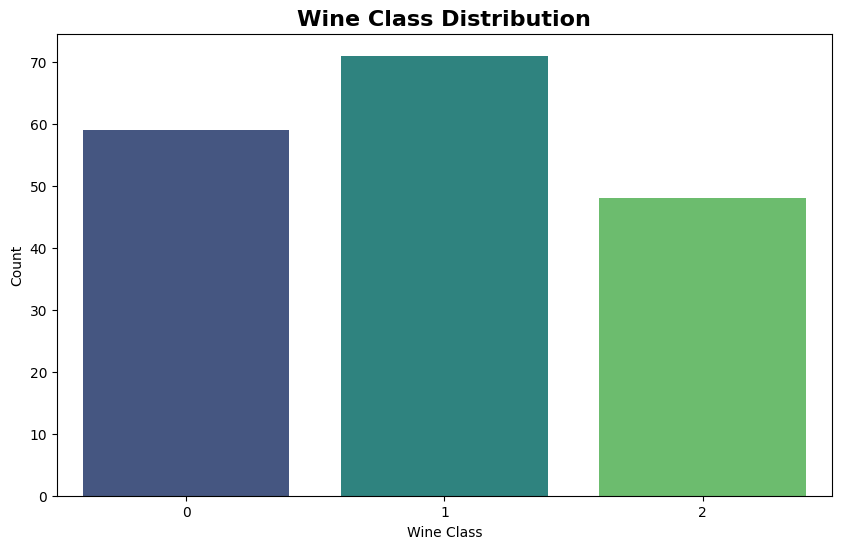

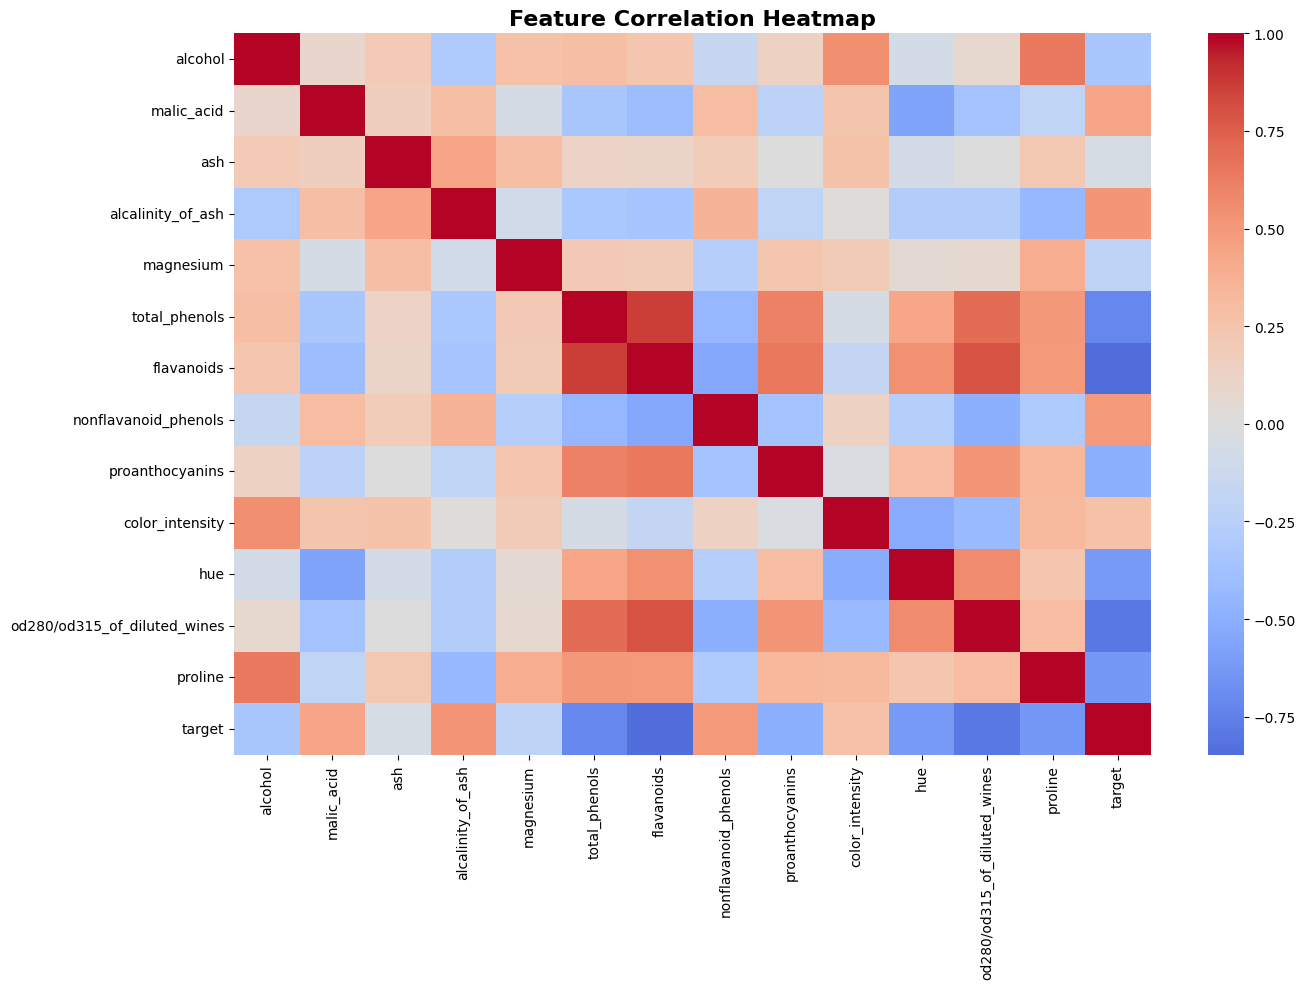

In [3]:
# Class distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='target', data=wine_df, palette='viridis')
plt.title('Wine Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.show()

# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(wine_df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# Separate features and target
X = wine_df.drop('target', axis=1)
y = wine_df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Data prepared!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

✓ Data prepared!
Training set: 142 samples
Test set: 36 samples


In [5]:
# Train SVM model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("✓ SVM Model trained successfully!")

✓ SVM Model trained successfully!


Model Accuracy: 0.9722 (97.22%)

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



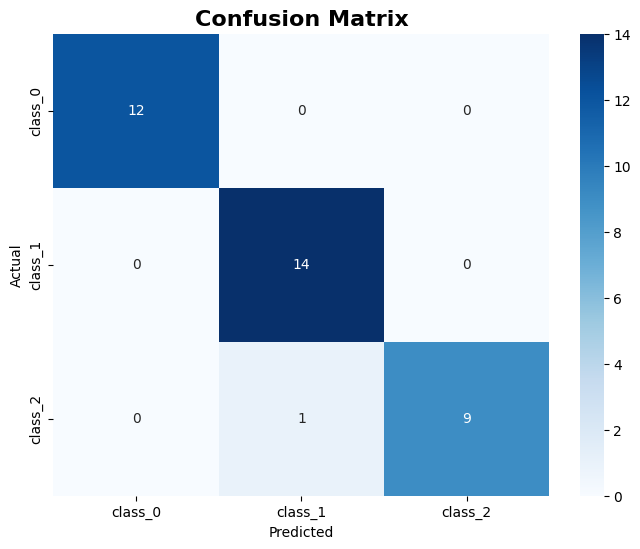

In [6]:
# Make predictions
y_pred = svm_model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [7]:
# Create model package
model_package = {
    'model': svm_model,
    'scaler': scaler,
    'feature_names': list(data.feature_names),
    'target_names': list(data.target_names),
    'accuracy': accuracy,
    'algorithm': 'Support Vector Machine (SVM)',
    'kernel': 'RBF'
}

# Save as pickle
with open('wine_cultivar_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("✓ Model saved as 'wine_cultivar_model.pkl'")
print(f"✓ Accuracy: {accuracy*100:.2f}%")

✓ Model saved as 'wine_cultivar_model.pkl'
✓ Accuracy: 97.22%


In [8]:
# Verify saved model works
with open('wine_cultivar_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

# Test prediction
test_pred = loaded['model'].predict(X_test_scaled[:5])
print("Test predictions:", test_pred)
print("Actual values:   ", y_test[:5].values)
print("\n✓ Model loads and works correctly!")

Test predictions: [0 2 0 1 1]
Actual values:    [0 2 0 1 1]

✓ Model loads and works correctly!
